Bien que les images FIB/SEM soient initialement des volumes 3D de grande taille, le challenge fournit directement un ensemble d’imagettes 2D extraites autour de pixels annotés. Chaque imagette est associée à une étiquette correspondant à la classe du pixel central. Le problème est ainsi formulé comme une tâche de classification supervisée d’images 2D.

In [69]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import os
import pickle
import gzip
import urllib
from zipfile import ZipFile

import torchvision.transforms as TF
from torchvision.transforms import ToTensor, ToPILImage, Grayscale

device = ("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Run to install pydot
!pip install pydot-ng
!pip install graphviz
!pip install torchsummary

In [71]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

# Fonction de chargement
def load_data_from_folder(csv_path, img_dir):
    df = pd.read_csv(csv_path)

    data = []
    labels = []

    print(f"Chargement de {len(df)} images depuis {img_dir}...")

    # Boucle sur chaque ligne du CSV
    for index, row in tqdm(df.iterrows(), total=len(df)):
        img_id = row['ID']
        category = row['Category']

       
        filename = f"{img_id}.png"
        filepath = os.path.join(img_dir, filename)

        try:
            #Ouvre l'image et converti en niveaux de gris
            img = Image.open(filepath).convert('L')

            # Transformer en tableau Numpy
            img_array = np.array(img)

            data.append(img_array)
            labels.append(category)

        except FileNotFoundError:
            continue

    # On convertit les listes en tableaux Numpy
    return np.array(data), np.array(labels)


base_dir = "/kaggle/input/2025-competition-apprentissage-i-3-d"

img_dir_kaggle = os.path.join(base_dir, "train") 
csv_file_kaggle = os.path.join(base_dir, "train.csv")

# LAUNCH

if os.path.exists(csv_file_kaggle):
    print("Fichier CSV trouvé")
    X_train, y_train = load_data_from_folder(csv_file_kaggle, img_dir_kaggle)

    print(f"Images chargées : {X_train.shape}") 
    print(f"Labels chargés : {y_train.shape}")
else:
    print(f"Fichier CSV non trouvé: {csv_file_kaggle}")

Fichier CSV trouvé
Chargement de 14000 images depuis /kaggle/input/2025-competition-apprentissage-i-3-d/train...


100%|██████████| 14000/14000 [00:40<00:00, 349.60it/s]


Images chargées : (14000, 257, 257)
Labels chargés : (14000,)


In [72]:
N = len(X_train)

# Random mix des indices x_train
indices_melanges = np.random.permutation(N)

# On applique le mix
X_train = X_train[indices_melanges]
y_train = y_train[indices_melanges]

print("Dataset mélangé")

Dataset mélangé


In [73]:
from sklearn.model_selection import train_test_split

print(f"Total des images avant découpage : {len(X_train)}")

# Découpage automatique
# test_size=0.05 signifie qu'on garde 15% pour la validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,       
    y_train,      
    test_size=0.05, # 5% pour la validation 
    random_state=39, # Pour que le mélange soit toujours le même
    stratify=y_train # On conserve les proportions
)

# Affichage de la Shape
print("-" * 30)
print(f"Train set shape : data={X_train_final.shape}, label={y_train_final.shape}")
print(f"Val set shape   : data={X_val.shape}, label={y_val.shape}")
print("-" * 30)

# Petit check pour etre sur
print("Pourcentage de chaque classe dans le set de Validation :")
print(pd.Series(y_val).value_counts(normalize=True) * 100)

Total des images avant découpage : 14000
------------------------------
Train set shape : data=(13300, 257, 257), label=(13300,)
Val set shape   : data=(700, 257, 257), label=(700,)
------------------------------
Pourcentage de chaque classe dans le set de Validation :
0    48.000000
1    27.000000
2    10.857143
4     9.142857
3     5.000000
Name: proportion, dtype: float64


In [74]:
import torch
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor

class FIBSEMDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        # On applique au minimum ToTensor()
        self.transform = transform if transform is not None else ToTensor()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # On récupère l'image le label à l'index idx
        img = self.data[idx]
        label = self.labels[idx]

        # Transformation des données
        # Si tes données sont des numpy arrays uint8 (0-255), c'est parfait.
        img_tensor = self.transform(img)

        # Le label doit être en long pour la CrossEntropyLoss
        return img_tensor, torch.tensor(label, dtype=torch.long)

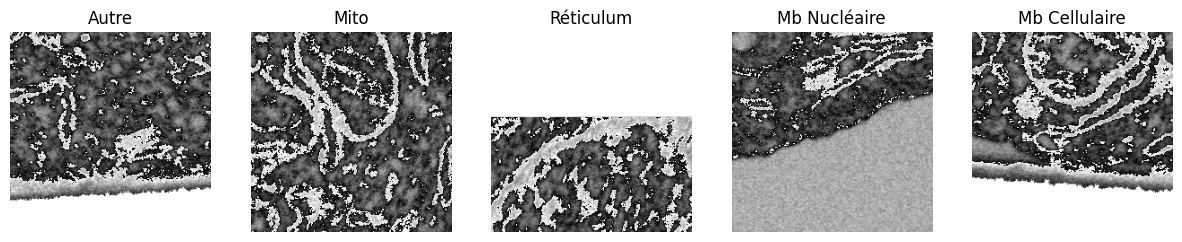

In [75]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
from torchvision import transforms
from torchvision import transforms

# Définition des transformations pour l'entraînement
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),     
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),

])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),     
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

train_set = FIBSEMDataset(X_train_final, y_train_final, transform=train_transforms)
val_set = FIBSEMDataset(X_val, y_val, transform=val_transforms)

classes_names = {0: "Autre", 1: "Mito", 2: "Réticulum", 3: "Mb Nucléaire", 4: "Mb Cellulaire"}

plt.figure(figsize=(15, 3)) # On affiche les 5 images

for class_id in range(5):
    # On cherche l'index du premier élément qui correspond à la classe 'class_id'
    # np.where renvoie les indices, on prend le premier [0][0]
    idx = np.where(y_train_final == class_id)[0][0]

    # On récupère l'image et le label dans le dataset
    img_tensor, label_tensor = train_set[idx]

    # Affichage dans une sous-fenêtre (1 ligne, 5 colonnes)
    plt.subplot(1, 5, class_id + 1)

    # On convertit le Tensor en image PIL pour l'affichage
    # cmap='gray' est important pour voir le noir et blanc correct
    plt.imshow(ToPILImage()(img_tensor), cmap='gray')

    plt.title(f"{classes_names[class_id]}")
    plt.axis('off') # Enlève les axes pour faire propre

plt.show()

In [76]:
# Create train & val & test sets dataloaders
from torch.utils.data import DataLoader
bs = 64

# On recréer les loaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2,pin_memory=True)

val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=1, pin_memory=True)


# On récupère le premier paquet d'images pour voir sa forme
images_batch, labels_batch = next(iter(train_loader))

print(f"Taille d'un batch d'images : {images_batch.shape}")
print(f"Taille d'un batch de labels : {labels_batch.shape}")

Taille d'un batch d'images : torch.Size([64, 1, 224, 224])
Taille d'un batch de labels : torch.Size([64])


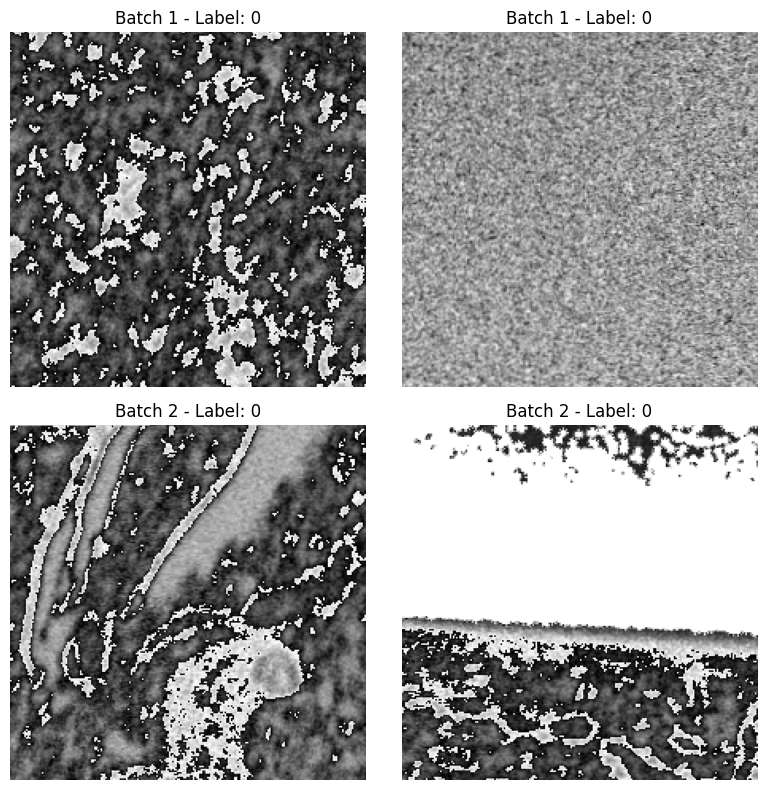

In [77]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage

# On crée l'itérateur
dataiter = iter(train_loader)

plt.figure(figsize=(8, 8))

#  Premier Batch 
images, labels = next(dataiter)

# Image 1 du Batch 1
plt.subplot(2, 2, 1)
plt.imshow(ToPILImage()(images[0]), cmap='gray')
plt.title(f"Batch 1 - Label: {labels[0].item()}")
plt.axis('off')

# Image 2 du Batch 1
plt.subplot(2, 2, 2)
plt.imshow(ToPILImage()(images[1]), cmap='gray')
plt.title(f"Batch 1 - Label: {labels[1].item()}")
plt.axis('off')

# Deuxième Batch
# On appelle next() une 2ème fois pour passer au paquet suivant
images, labels = next(dataiter)

# Image 1 du Batch 2
plt.subplot(2, 2, 3)
plt.imshow(ToPILImage()(images[0]), cmap='gray')
plt.title(f"Batch 2 - Label: {labels[0].item()}")
plt.axis('off')

# Image 2 du Batch 2
plt.subplot(2, 2, 4)
plt.imshow(ToPILImage()(images[1]), cmap='gray')
plt.title(f"Batch 2 - Label: {labels[1].item()}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [78]:
# On ne se sert pas de ce modèle pour la suite de l'entrainemet
# On le laisse pour montrer le processus de recherche

import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CNN, self).__init__()

        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Divise taille par 2 (128->64)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Divise taille par 2 (64->32)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Divise taille par 2 (32->16)

  
        # Image départ 128x128 -> pool1 -> 64x64 -> pool2 -> 32x32 -> pool3 -> 16x16
        # On a 128 canaux à la fin.
        # Donc la taille aplatie est : 128 * 16 * 16 = 32768

        self.flatten_size = 128 * 16 * 16

        self.linear1 = nn.Linear(self.flatten_size, 512)
        self.dropout = nn.Dropout(0.5) # Ajouté pour éviter le par-coeur
        self.linear2 = nn.Linear(512, num_classes) # 5 classes

    def forward(self, x):
        # Bloc 1
        x = self.relu(self.conv1(x))
        x = self.pool1(x)

        # Bloc 2
        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        # Bloc 3
        x = self.relu(self.conv3(x))
        x = self.pool3(x)

        # Aplatissement
        x = x.reshape(x.shape[0], -1)

        # Dense layers
        x = self.relu(self.linear1(x))
        x = self.dropout(x) # Important !
        x = self.linear2(x)

        return x

# Sanity Check
# On teste avec la vraie taille de tes images (128x128) et 1 canal
x_test = torch.randn(64, 1, 128, 128)
model = CNN(num_classes=5)
out = model(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {out.shape}")

Input shape: torch.Size([64, 1, 128, 128])
Output shape: torch.Size([64, 5])


In [79]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, resnet50

class ResNet18Gray(nn.Module):
    def __init__(self, num_classes=5, pretrained=False):
        super().__init__()

        # modèle connu
        self.model = resnet18(weights="DEFAULT" if pretrained else None)

        # On adapte l'entrée à 1 canal
        old_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        # Si pretrained=True, il faut initialiser conv1 à partir des poids RGB
        if pretrained:
            with torch.no_grad():
                self.model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

        # On adapte la sortie à 5 classes
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [ ]:
from torchsummary import summary
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

cnn = ResNet18Gray(num_classes=5, pretrained=False).to(device)

x_test = torch.randn(64, 1, 224, 224).to(device)

out = cnn(x_test)
print(f"Input shape:  {x_test.shape}")
print(f"Output shape: {out.shape}")
print("ResNet-50 grayscale chargé !")

# summary
summary(cnn, (1, 224, 224))

In [ ]:
#Envoi sur le GPU
cnn.to(device)

In [82]:
def accuracy(loader, model, device):
    was_training = model.training
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    if was_training:
        model.train()
    return correct / total


In [83]:
import torch
import torch.nn as nn
import torch.optim as optim


# Calculer combien il y a d'exemples de chaque classe
class_counts = np.bincount(y_train_final)
total_samples = len(y_train_final)

print(f"Nombre d'images par classe : {class_counts}")

# Calcule de poids 
# Moins il y a d'images, plus le poids est lourd
# poids inverses (plus la classe est rare, plus son poids est grand)
w = 1.0 / (class_counts + 1e-12)

# moyenne = 1 (stable)
w = w / w.mean()

weights_tensor = torch.tensor(w, dtype=torch.float32, device=device)
print("class_counts:", class_counts)
print("weights_tensor:", weights_tensor)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Nombre d'images par classe : [6375 3600 1451  656 1218]
class_counts: [6375 3600 1451  656 1218]
weights_tensor: tensor([0.2261, 0.4003, 0.9933, 2.1970, 1.1833], device='cuda:0')


In [ ]:
import time
import copy

# Historiques pour les graphiques
loss_train_history = []
loss_val_history = []
acc_train_history = []
acc_val_history = []
lr_history = []

best_val_loss = float("inf")
best_val_acc = 0.0

best_loss_state = None
best_acc_state  = None

no_improvement = 0
patience = 8
min_delta = 1e-4
epochs=45


warmup_lr = 5e-3
base_lr = 5e-4              #  LR
warmup_epochs = 1           # 1 epoch is enough
warmup_steps = warmup_epochs * len(train_loader)

global_step = 0

optimizer = torch.optim.Adam(cnn.parameters(), lr=base_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,     # lr = lr * 0.5
    patience=3,     # attend 2 epochs sans amélioration
    min_lr=1e-6
)


print("Démarrage de l'entraînement...")
start_time = time.time()

for epoch in range(epochs):

    cnn.train() # Mode entraînement
    running_loss = 0.0
    
    
    # Boucle d'entrainement
    for i, data in enumerate(train_loader, 0):
        # On récupère les données
        inputs, labels = data[0].to(device), data[1].to(device)

        if global_step < warmup_steps:
            warmup_lr = base_lr * (global_step + 1) / warmup_steps
            optimizer.param_groups[0]["lr"] = warmup_lr


        global_step += 1
        
        # Remise à zéro des gradients
        optimizer.zero_grad()

        # Forward (Prédiction)
        outputs = cnn(inputs)

        # Calcul de la perte 
        loss = criterion(outputs, labels)

        # Backward 
        loss.backward()

        # Optimization
        optimizer.step()

        # Statistique
        running_loss += loss.item()

    # Calcul de la perte moyenne sur l'époque
    epoch_loss = running_loss / len(train_loader)
    loss_train_history.append(epoch_loss)

        
    # Boucle de validation
    cnn.eval() 
    running_val_loss = 0.0

    with torch.no_grad(): 
        for data in val_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = cnn(inputs)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()
    
    # Calcul de la perte moyenne de validation
    epoch_val_loss = running_val_loss / len(val_loader)
    loss_val_history.append(epoch_val_loss)
    # après calcul epoch_val_loss
    if epoch >= warmup_epochs:
        scheduler.step(epoch_val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print("lr =", current_lr)
    lr_history.append(current_lr)

    #Early stoping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        no_improvement = 0
        best_loss_state = copy.deepcopy(cnn.state_dict())

    else:
        no_improvement += 1

    
    # Calcul de l'accuracy
    epoch_train_acc = accuracy(train_loader, cnn, device)
    epoch_val_acc = accuracy(val_loader, cnn, device)
        
    acc_train_history.append(epoch_train_acc)
    acc_val_history.append(epoch_val_acc)
    # Best Accuracy
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_acc_state  = copy.deepcopy(cnn.state_dict())

    print(f"Epoch [{epoch+1}] "
          f"Loss Train: {epoch_loss:.4f} | Loss Val: {epoch_val_loss:.4f} | "
          f"Acc Train: {epoch_train_acc*100:.2f}% | Acc Val: {epoch_val_acc*100:.2f}%")
    # Balanced accuracy

    if no_improvement >= patience:
        print(f"Early stopping à epoch {epoch+1} | best val_loss={best_val_loss:.4f}")
        break
    
total_time = time.time() - start_time
print(f'Entraînement terminé en {total_time/60:.0f} minutes')

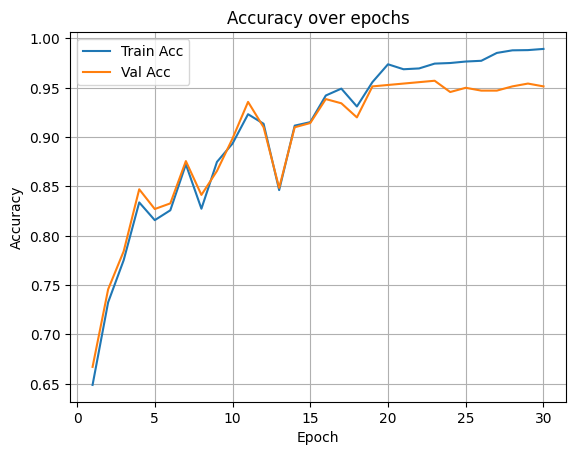

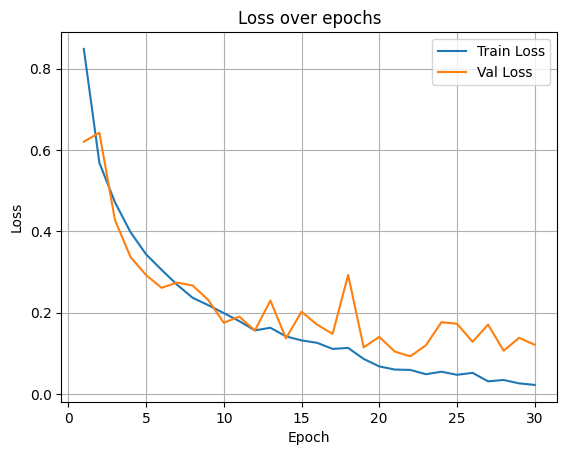

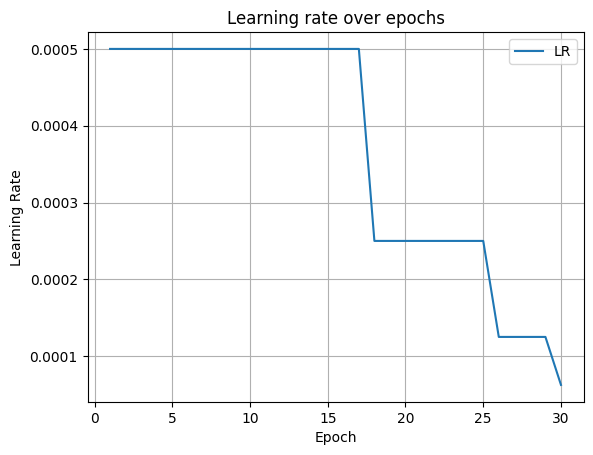

In [85]:
import matplotlib.pyplot as plt

# Nombre réel d'epochs effectuées
n_epochs_done = len(loss_train_history)
epochs_axis = np.arange(1, n_epochs_done + 1)

# accuracy
plt.figure()
plt.plot(epochs_axis, acc_train_history[:n_epochs_done], label="Train Acc")
plt.plot(epochs_axis, acc_val_history[:n_epochs_done], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.grid(True)
plt.show()

# loss 
plt.figure()
plt.plot(epochs_axis, loss_train_history[:n_epochs_done], label="Train Loss")
plt.plot(epochs_axis, loss_val_history[:n_epochs_done], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.grid(True)
plt.show()

# learning rate
plt.figure()
plt.plot(epochs_axis, lr_history[:n_epochs_done], label="LR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning rate over epochs")
plt.legend()
plt.grid(True)
plt.show()


In [86]:
cnn.load_state_dict(best_acc_state)
print(f"Loaded best ACC model = {best_val_acc*100:.2f}%")

Loaded best ACC model = 95.71%


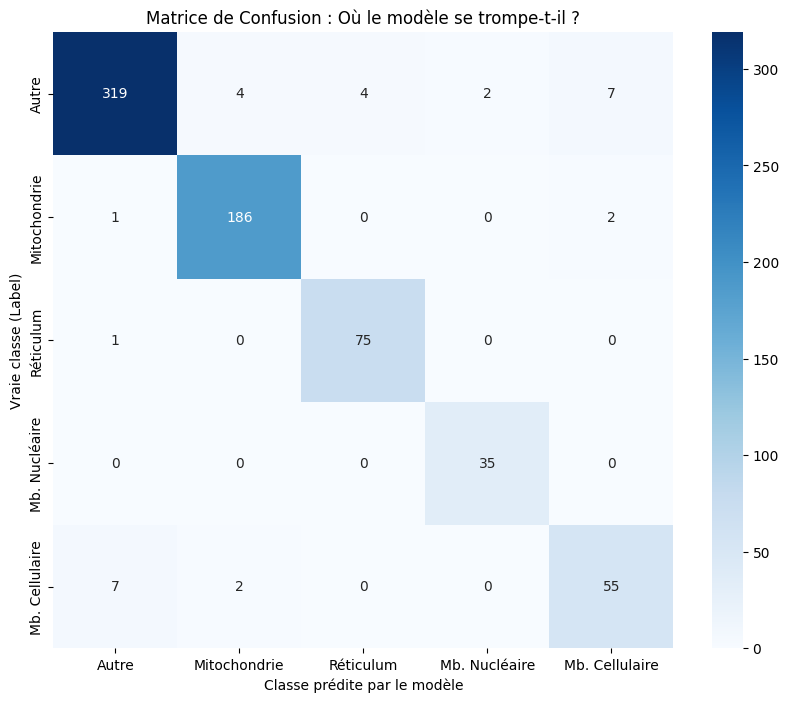

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Récupérer toutes les prédictions du Val Set
y_pred = []
y_true = []

cnn.eval() # Mode évaluation
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        # Prédictions
        outputs = cnn(inputs)
        _, predicted = torch.max(outputs, 1)

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

classes = ["Autre", "Mitochondrie", "Réticulum", "Mb. Nucléaire", "Mb. Cellulaire"]

# Créer la matrice
cm = confusion_matrix(y_true, y_pred)

# Affichage avec Seaborn
plt.figure(figsize=(10, 8))
df_cm = pd.DataFrame(cm, index=classes, columns=classes)

# Heatmap : Plus c'est foncé, plus il y a d'images
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion : Où le modèle se trompe-t-il ?')
plt.ylabel('Vraie classe (Label)')
plt.xlabel('Classe prédite par le modèle')
plt.show()

In [88]:
# Sauvegarde des poids du modèle
torch.save(cnn.state_dict(), 'fisem_model_88acc.pth')
print("Modèle sauvegardé sous 'fisem_model_88acc.pth'")

Modèle sauvegardé sous 'fisem_model_88acc.pth'


In [ ]:
import os
from PIL import Image
from tqdm import tqdm
import re


dest_dir = "/kaggle/input/2025-competition-apprentissage-i-3-d/test/"

def load_test_data_no_csv(img_dir):
    # Liste tous les fichiers
    all_files = os.listdir(img_dir)

    # Filtre pour ne garder que les images
    image_files = [f for f in all_files if f.lower().endswith(('.png', '.tif', '.tiff', '.jpg'))]

    # On trie pour avoir l'ordre 1, 2, 3
    image_files.sort(key=lambda f: int(re.sub('\D', '', f)) if re.search('\d', f) else f)

    data = []
    ids = []

    print(f"Chargement de {len(image_files)} images depuis {img_dir}...")

    for filename in tqdm(image_files):
        filepath = os.path.join(img_dir, filename)

        try:
            img = Image.open(filepath).convert('L')

            img = img.resize((224, 224))

            img_array = np.array(img)

            try:
                img_id = int(re.search(r'\d+', filename).group())
            except:
                img_id = filename
                
            data.append(img_array)
            ids.append(img_id)

        except Exception as e:
            print(f"Erreur sur {filename}: {e}")
            continue

    # On retourne les images et les ids
    return np.array(data), np.array(ids)


In [ ]:
import os


# check du path
if os.path.exists(dest_dir):
    print(f"Chemin trouvé ! 'dest_dir' pointe vers : {dest_dir}")
    print(f"Il contient {len(os.listdir(dest_dir))} images.")
    print("Lancement du chargement")
    X_test, test_ids = load_test_data_no_csv(dest_dir)
    print(f"Succès ! {X_test.shape[0]} images chargées.")
else:
    print("ERREUR : Le chemin est introuvable.")

In [91]:
from torchvision import transforms

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),    
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


#On redéfinit la classe Dataset
class TestDataset(Dataset):
    def __init__(self, images, ids, transform=None):
        self.images = images
        self.ids = ids
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        id_val = self.ids[idx]
        if self.transform:
            img = self.transform(img)
        return img, id_val

# Creation du loader
if 'X_test' in globals():
    test_dataset_kaggle = TestDataset(X_test, test_ids, transform=val_transforms)

    test_loader_kaggle = DataLoader(
        test_dataset_kaggle, 
        batch_size=64, 
        shuffle=False,
        num_workers=1
    )
    print("'test_loader_kaggle' crée.")
else:
    print(" ERREUR : La variable X_test n'existe pas.")


'test_loader_kaggle' crée.


In [92]:
import torch
import torch.nn.functional as F 

# modèle en mode évaluation
cnn.eval()

all_predictions = []
all_ids = []

print(" Lancement des prédictions avec TTA (Moyenne de 4 vues)...")

with torch.no_grad():
    for images, ids in tqdm(test_loader_kaggle):
        images = images.to(device)
        
        # L'image originale
        output_1 = cnn(images)
        
        # Miroir Horizontal
        img_flip_h = torch.flip(images, [3]) 
        output_2 = cnn(img_flip_h)
        
        # Miroir Vertical
        img_flip_v = torch.flip(images, [2])
        output_3 = cnn(img_flip_v)
        
        #Rotation 180° 
        img_flip_hv = torch.flip(images, [2, 3])
        output_4 = cnn(img_flip_hv)

        # Moyenne
        avg_output = (output_1 + output_2 + output_3 + output_4)

        # On prend la classe gagnante sur la moyenne
        _, predicted = torch.max(avg_output.data, 1)

        # Stockage
        all_predictions.extend(predicted.cpu().numpy())
        all_ids.extend(ids)

print(" Prédictions TTA terminées !")


submission_df = pd.DataFrame({
    'ID': all_ids,
    'Category': all_predictions
})


 Lancement des prédictions avec TTA (Moyenne de 4 vues)...


100%|██████████| 94/94 [00:20<00:00,  4.70it/s]

 Prédictions TTA terminées !


In [93]:

submission_df['ID'] = submission_df['ID'].apply(lambda x: x.item() if hasattr(x, 'item') else x)

print(submission_df.head())

# On sauvegarde le fichier 
submission_df.to_csv('submission_clean.csv', index=False)


   ID  Category
0   1         1
1   2         0
2   5         4
3   9         4
4  13         0
